# 1. Funções de Pertinência

## 1.1 Implementação de Funções de Pertinência

Implemente funções para calcular o grau de pertinência de um valor em cada uma das funções a seguir:

- **Triangular**
- **Trapezoidal**
- **Gaussiana**
- **Sigmoidal**
- **Sinoidal (Bell)**
- **Função S**
- **Função Z**
- **Cauchy**
- **Gaussiana Dupla**
- **Definida pelo Usuário 1**
- **Definida pelo Usuário 2**

## 1.2 Fuzzificação e Análise Comparativa

Escolha uma variável de entrada e defina seu universo de discurso. Particione esse domínio em pelo menos quatro funções de pertinência uniformemente espaçadas, com base em cada um dos tipos implementados na Atividade 1.1.

- Realize a fuzzificação de duas amostras distintas, ou seja, calcule o grau de ativação de cada função de pertinência para os valores de entrada escolhidos.
- Apresente, para cada tipo de função de pertinência, gráficos mostrando o universo de discurso, as funções de pertinência e a ativação das entradas.
- Escreva uma análise textual comparando os resultados: como o grau de ativação varia entre diferentes funções? Quais têm maior suavidade ou sensibilidade à variação?

# 2. Operações Fuzzy

## 2.1 Complemento, União e Interseção

Implemente funções para as seguintes operações fuzzy, com base nos conjuntos fuzzy definidos anteriormente. Use os valores dos graus de pertinência para cada ponto do universo de discurso.

- **Complemento:**
  - Zadeh
  - Sugeno
  - Yager
- **União (t-conormas):**
  - Máximo
  - Soma Probabilística
  - Soma Limitada
  - Soma Drástica
- **Interseção (t-normas):**
  - Mínimo
  - Produto
  - Produto Limitado
  - Produto Drástica

Apresente uma análise gráfica e textual comparativa entre os operadores, utilizando conjuntos fuzzy criados anteriormente.

## 2.2 Relações Fuzzy

Implemente uma função que calcule a matriz de uma relação fuzzy entre dois conjuntos. A função deve receber:

- O operador t-norma a ser utilizado;
- Os graus de pertinência dos elementos dos dois conjuntos fuzzy.

A função deve retornar a matriz resultante da relação. Utilize pelo menos dois operadores t-norma (ex: mínimo e produto) e dois operadores s-norma (ex: máximo e soma probabilística) para comparar os resultados. Apresente os resultados graficamente e com uma análise comparativa.

## 2.3 Composição de Relações Fuzzy

Implemente funções para as composições:

- Máximo-Mínimo: μR(x, z) = maxy min(μA(x, y), μB(y, z))
- Mínimo-Máximo: μR(x, z) = miny max(μA(x, y), μB(y, z))
- Máximo-Produto: μR(x, z) = maxy μA(x, y) · μB(y, z)

Utilize o mesmo exemplo de conjuntos fuzzy para aplicar as três composições. Compare os resultados obtidos graficamente e em análise textual.

# 1. Funções de Pertinência

## 1.1 Implementação de Funções de Pertinência

In [26]:
def gerar_parametros(intervalo, tipo, n):
    """
    Gera parâmetros uniformemente espaçados para funções de pertinência fuzzy.

    Args:
        intervalo (tuple): (min, max) do universo de discurso.
        tipo (str): Tipo da função ('triangular', 'trapezoidal', 'gaussiana', etc).
        n (int): Quantidade de funções.

    Returns:
        list: Lista de tuplas de parâmetros para cada função.
    """
    xmin, xmax = intervalo
    step = (xmax - xmin) / (n - 1)
    centers = np.linspace(xmin, xmax, n)
    params = []
    if tipo == 'triangular':
        for i in range(n):
            a = centers[i-1] if i > 0 else xmin
            b = centers[i]
            c = centers[i+1] if i < n-1 else xmax
            params.append((a, b, c))
    elif tipo == 'trapezoidal':
        width = step
        for i in range(n):
            a = max(xmin, centers[i] - width)
            b = centers[i] - width/2
            c = centers[i] + width/2
            d = min(xmax, centers[i] + width)
            params.append((a, b, c, d))
    elif tipo == 'gaussiana':
        sigma = step
        for c in centers:
            params.append((c, sigma))
    elif tipo == 'sigmoidal':
        a = 1
        for c in centers:
            params.append((a, c))
    elif tipo == 'bell':
        a = step/2
        b = 2
        for c in centers:
            params.append((a, b, c))
    elif tipo == 's':
        for i in range(n):
            a = centers[i] - step/2
            b = centers[i] + step/2
            params.append((a, b))
    elif tipo == 'z':
        for i in range(n):
            a = centers[i] - step/2
            b = centers[i] + step/2
            params.append((a, b))
    elif tipo == 'cauchy':
        gamma = step
        for c in centers:
            params.append((c, gamma))
    elif tipo == 'gaussiana_dupla':
        sigma = step/2
        for i in range(n):
            m1 = centers[i] - step/3
            m2 = centers[i] + step/3
            params.append((m1, sigma, m2, sigma))
    elif tipo == 'user1':
        for i in range(n):
            a = max(xmin, centers[i] - step/2)
            b = min(xmax, centers[i] + step/2)
            params.append((a, b))
    elif tipo == 'user2':
        for i in range(n):
            a = max(xmin, centers[i] - step/2)
            b = min(xmax, centers[i] + step/2)
            params.append((a, b))
    return params


import matplotlib.pyplot as plt
import os

def plot_funcoes(x, mus, params, nome, cor=None):
    import numbers
    def format_param(p):
        if isinstance(p, (tuple, list)):
            return "(" + ", ".join(f"{float(v):.2f}" if isinstance(v, numbers.Number) else str(v) for v in p) + ")"
        elif isinstance(p, numbers.Number):
            return f"{float(p):.2f}"
        return str(p)
    plt.figure(figsize=(8, 4))
    for i, mu in enumerate(mus):
        label = f'{nome} {i+1} {format_param(params[i])}'
        plt.plot(x, mu, label=label, color=cor[i] if cor else None)
    plt.title(f'Funções de pertinência - {nome}')
    plt.xlabel('x')
    plt.ylabel('Grau de pertinência')
    plt.legend()
    plt.grid(True)
    # Salvar na pasta img (cria se não existir)
    base_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
    img_dir = os.path.join(base_dir, "img")
    if not os.path.exists(img_dir):
        os.makedirs(img_dir)
    plt.savefig(os.path.join(img_dir, f"{nome.replace(' ', '_').lower()}.png"), bbox_inches='tight')
    plt.show()

In [27]:
import numpy as np

def triangular(x, a, b, c):
    return np.maximum(np.minimum((x - a) / (b - a + 1e-9), (c - x) / (c - b + 1e-9)), 0)

def trapezoidal(x, a, b, c, d):
    return np.maximum(np.minimum(np.minimum((x - a) / (b - a + 1e-9), 1), (d - x) / (d - c + 1e-9)), 0)

def gaussiana(x, c, sigma):
    return np.exp(-0.5 * ((x - c) / sigma) ** 2)

def sigmoidal(x, a, c):
    return 1 / (1 + np.exp(-a * (x - c)))

def bell(x, a, b, c):
    return 1 / (1 + np.abs((x - c) / a) ** (2 * b))

def s(x, a, b):
    y = np.zeros_like(x)
    idx1 = x <= a
    idx2 = (x > a) & (x < (a + b) / 2)
    idx3 = (x >= (a + b) / 2) & (x < b)
    idx4 = x >= b
    y[idx1] = 0
    y[idx2] = 2 * ((x[idx2] - a) / (b - a)) ** 2
    y[idx3] = 1 - 2 * ((b - x[idx3]) / (b - a)) ** 2
    y[idx4] = 1
    return y

def z(x, a, b):
    y = np.zeros_like(x)
    idx1 = x <= a
    idx2 = (x > a) & (x < (a + b) / 2)
    idx3 = (x >= (a + b) / 2) & (x < b)
    idx4 = x >= b
    y[idx1] = 1
    y[idx2] = 1 - 2 * ((x[idx2] - a) / (b - a)) ** 2
    y[idx3] = 2 * ((b - x[idx3]) / (b - a)) ** 2
    y[idx4] = 0
    return y

def cauchy(x, c, gamma):
    return 1 / (1 + ((x - c) / gamma) ** 2)

def gaussiana_dupla(x, m1, s1, m2, s2):
    return np.maximum(np.exp(-0.5 * ((x - m1) / s1) ** 2), np.exp(-0.5 * ((x - m2) / s2) ** 2))

def user1_linear_crescente(x, a, b):
    # Função definida pelo usuário 1: linear crescente
    return np.clip((x - a) / (b - a + 1e-9), 0, 1)

def user2_linear_decrescente(x, a, b):
    # Função definida pelo usuário 2: linear decrescente
    return np.clip((b - x) / (b - a + 1e-9), 0, 1)

# Exemplo de uso para cada função:
x = np.linspace(0, 40, 400)

# Triangular
params_tri = gerar_parametros((0, 40), 'triangular', 4)
mu_tri = [triangular(x, *p) for p in params_tri]

# Trapezoidal
params_trap = gerar_parametros((0, 40), 'trapezoidal', 4)
mu_trap = [trapezoidal(x, *p) for p in params_trap]

# Gaussiana
params_gauss = gerar_parametros((0, 40), 'gaussiana', 4)
mu_gauss = [gaussiana(x, *p) for p in params_gauss]

# Sigmoidal
params_sig = gerar_parametros((0, 40), 'sigmoidal', 4)
mu_sig = [sigmoidal(x, *p) for p in params_sig]

# Sinoidal (Bell)
params_bell = gerar_parametros((0, 40), 'bell', 4)
mu_bell = [bell(x, *p) for p in params_bell]

# Função S
params_s = gerar_parametros((0, 40), 's', 4)
mu_s = [s(x, *p) for p in params_s]

# Função Z
params_z = gerar_parametros((0, 40), 'z', 4)
mu_z = [z(x, *p) for p in params_z]

# Cauchy
params_cauchy = gerar_parametros((0, 40), 'cauchy', 4)
mu_cauchy = [cauchy(x, *p) for p in params_cauchy]

# Gaussiana Dupla
params_gd = gerar_parametros((0, 40), 'gaussiana_dupla', 4)
mu_gd = [gaussiana_dupla(x, *p) for p in params_gd]

# Definida pelo Usuário 1 (User1)
params_user1 = gerar_parametros((0, 40), 'user1', 4)
mu_user1 = [user1_linear_crescente(x, *p) for p in params_user1]

# Definida pelo Usuário 2 (User2)
params_user2 = gerar_parametros((0, 40), 'user2', 4)
mu_user2 = [user2_linear_decrescente(x, *p) for p in params_user2]

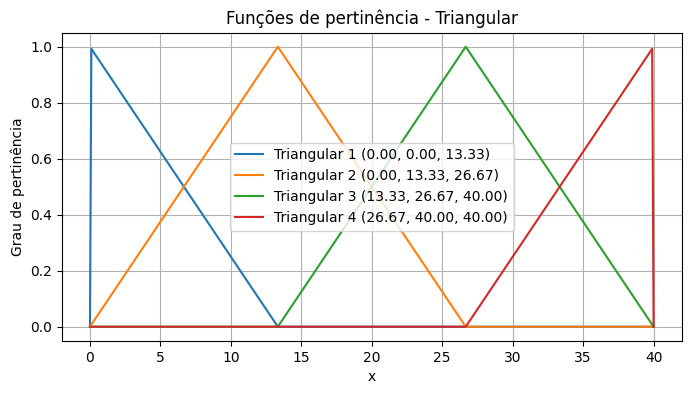

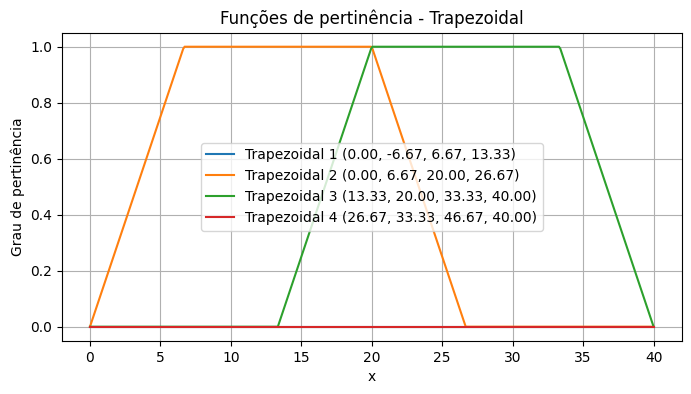

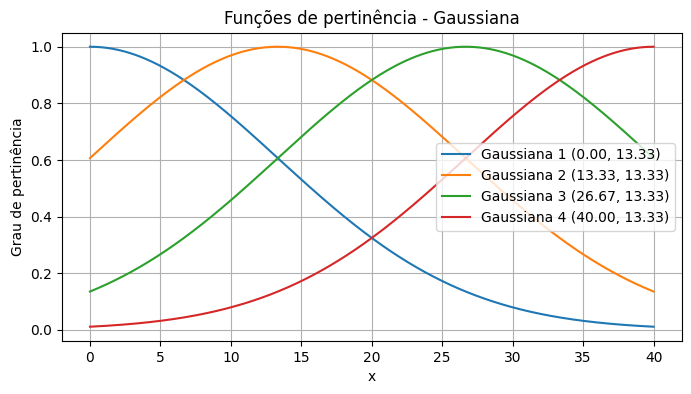

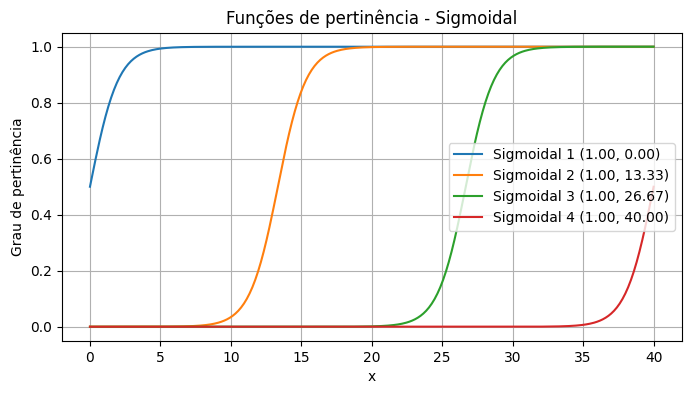

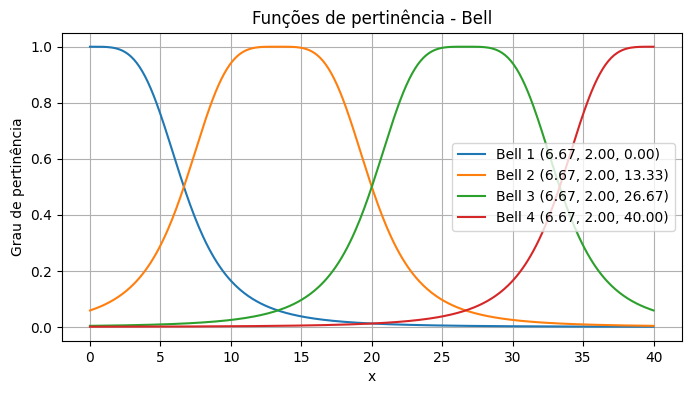

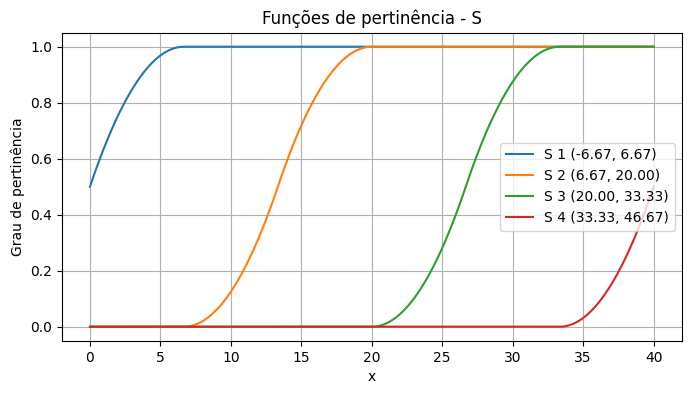

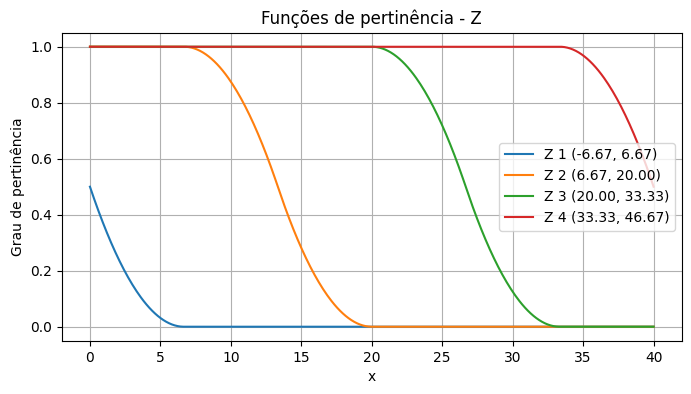

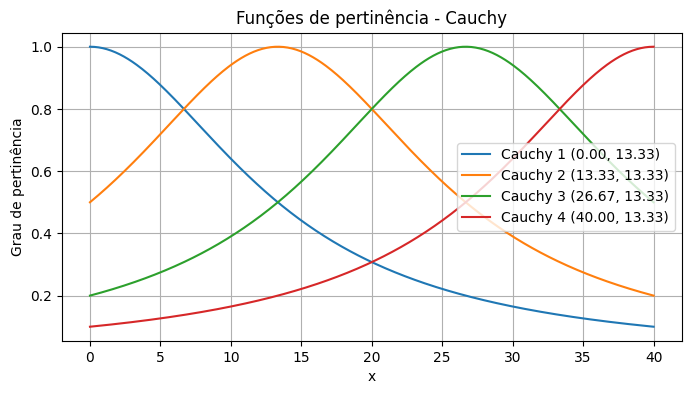

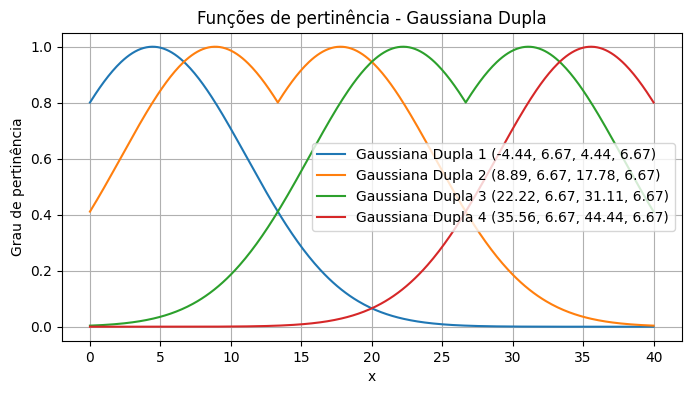

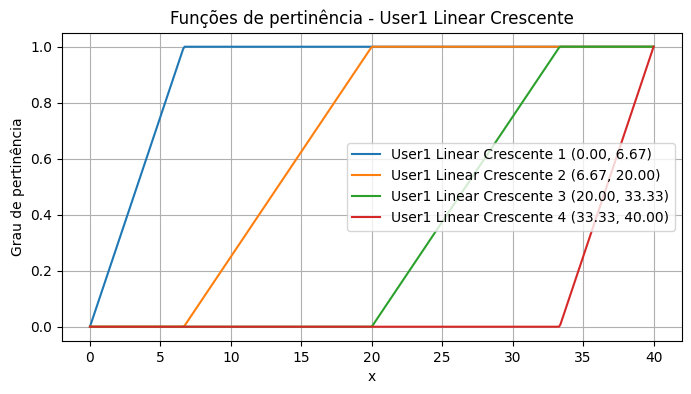

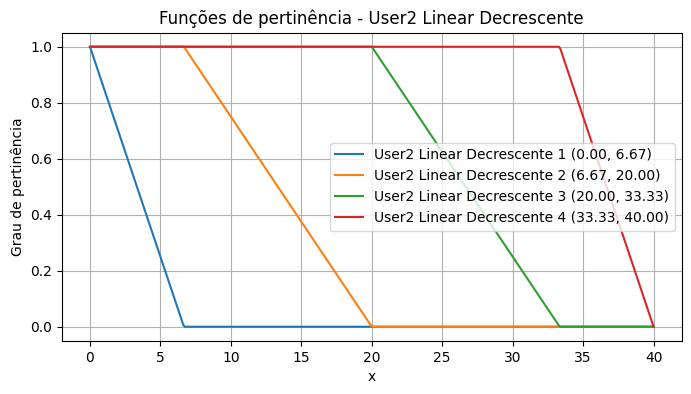

In [28]:
# Plotando cada tipo de função
plot_funcoes(x, mu_tri, params_tri, 'Triangular')
plot_funcoes(x, mu_trap, params_trap, 'Trapezoidal')
plot_funcoes(x, mu_gauss, params_gauss, 'Gaussiana')
plot_funcoes(x, mu_sig, params_sig, 'Sigmoidal')
plot_funcoes(x, mu_bell, params_bell, 'Bell')
plot_funcoes(x, mu_s, params_s, 'S')
plot_funcoes(x, mu_z, params_z, 'Z')
plot_funcoes(x, mu_cauchy, params_cauchy, 'Cauchy')
plot_funcoes(x, mu_gd, params_gd, 'Gaussiana Dupla')
plot_funcoes(x, mu_user1, params_user1, 'User1 Linear Crescente')
plot_funcoes(x, mu_user2, params_user2, 'User2 Linear Decrescente')

## 1.2 Fuzzificação e Análise Comparativa

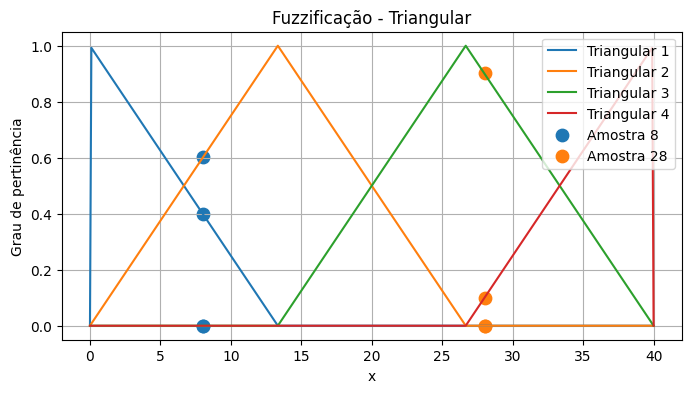

Amostra 8 (Triangular): ['0.398', '0.602', '0.000', '0.000']
Amostra 28 (Triangular): ['0.000', '0.000', '0.902', '0.098']


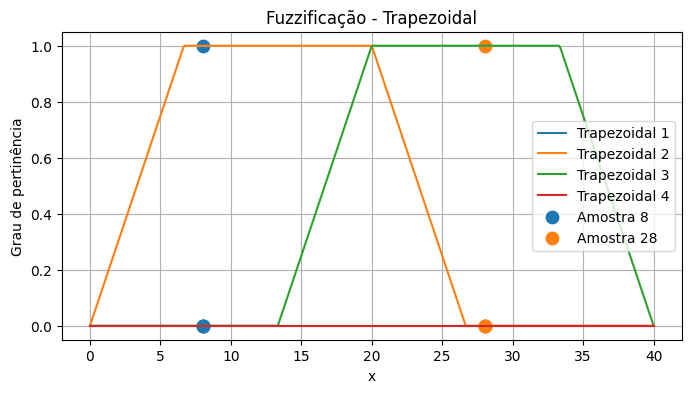

Amostra 8 (Trapezoidal): ['0.000', '1.000', '0.000', '0.000']
Amostra 28 (Trapezoidal): ['0.000', '0.000', '1.000', '0.000']


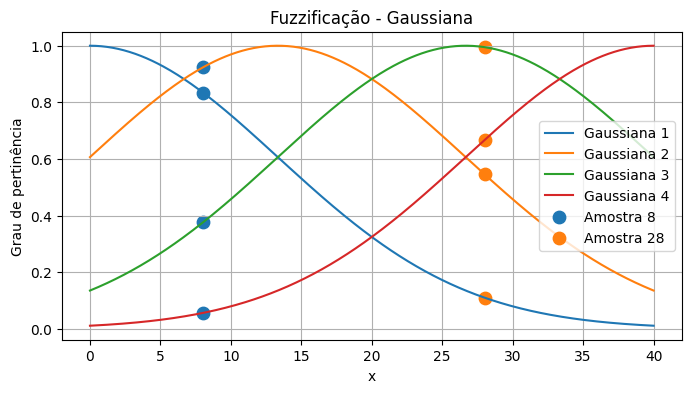

Amostra 8 (Gaussiana): ['0.835', '0.924', '0.376', '0.056']
Amostra 28 (Gaussiana): ['0.111', '0.547', '0.995', '0.666']


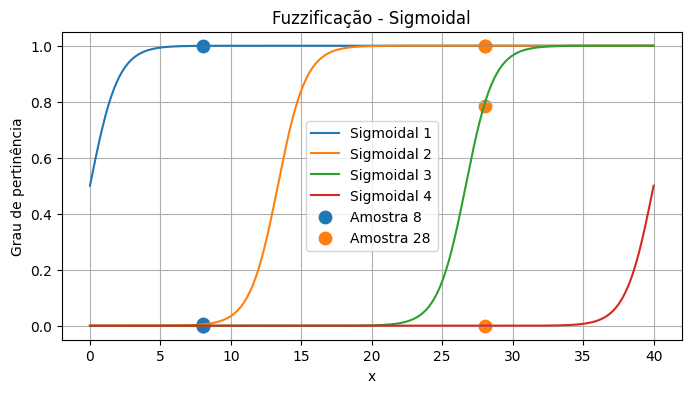

Amostra 8 (Sigmoidal): ['1.000', '0.005', '0.000', '0.000']
Amostra 28 (Sigmoidal): ['1.000', '1.000', '0.786', '0.000']


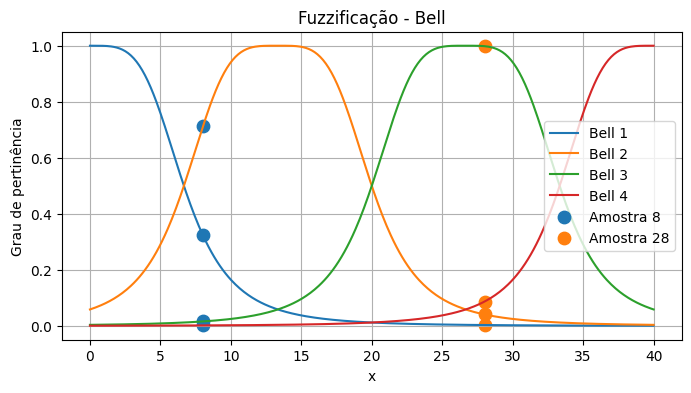

Amostra 8 (Bell): ['0.323', '0.713', '0.016', '0.002']
Amostra 28 (Bell): ['0.003', '0.041', '0.999', '0.086']


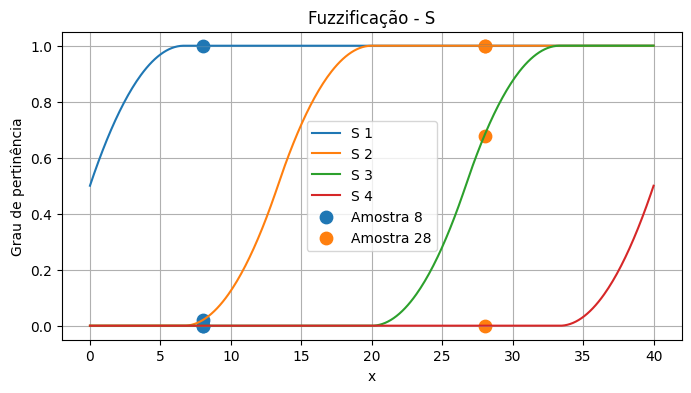

Amostra 8 (S): ['1.000', '0.021', '0.000', '0.000']
Amostra 28 (S): ['1.000', '1.000', '0.676', '0.000']


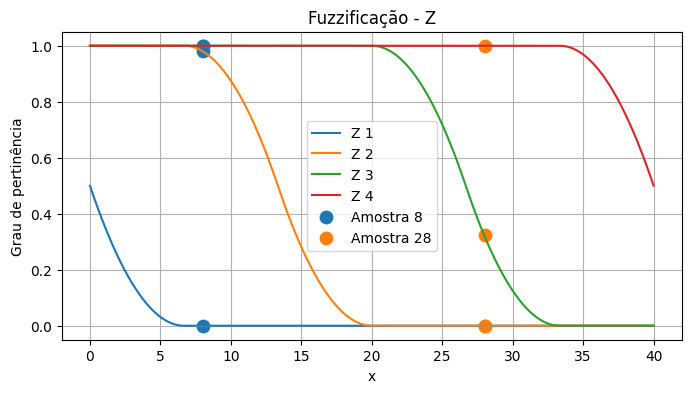

Amostra 8 (Z): ['0.000', '0.979', '1.000', '1.000']
Amostra 28 (Z): ['0.000', '0.000', '0.324', '1.000']


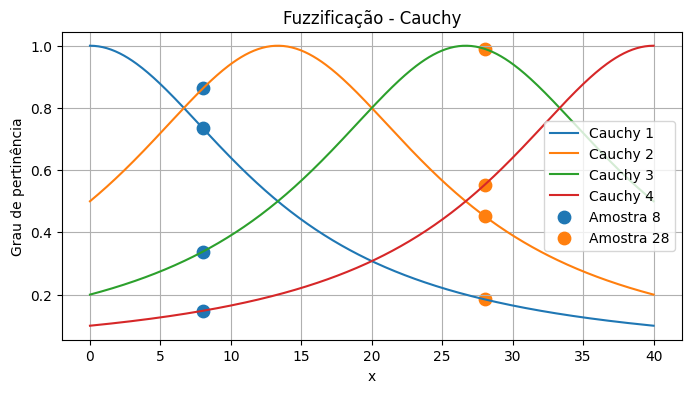

Amostra 8 (Cauchy): ['0.734', '0.863', '0.338', '0.148']
Amostra 28 (Cauchy): ['0.185', '0.454', '0.991', '0.551']


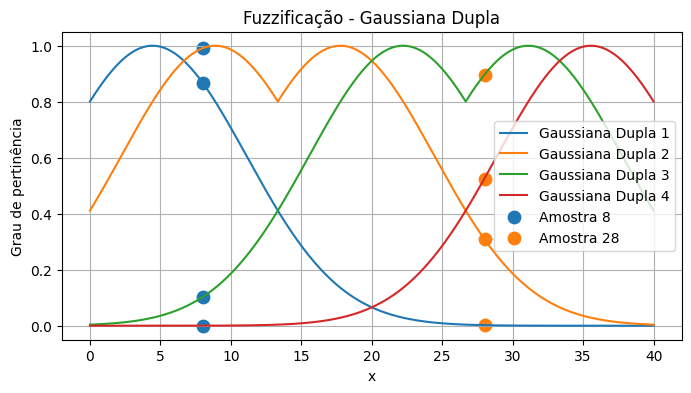

Amostra 8 (Gaussiana Dupla): ['0.866', '0.992', '0.103', '0.000']
Amostra 28 (Gaussiana Dupla): ['0.002', '0.311', '0.895', '0.523']


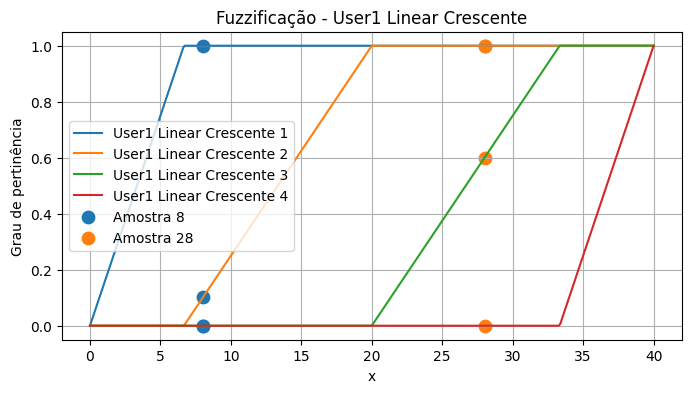

Amostra 8 (User1 Linear Crescente): ['1.000', '0.102', '0.000', '0.000']
Amostra 28 (User1 Linear Crescente): ['1.000', '1.000', '0.598', '0.000']


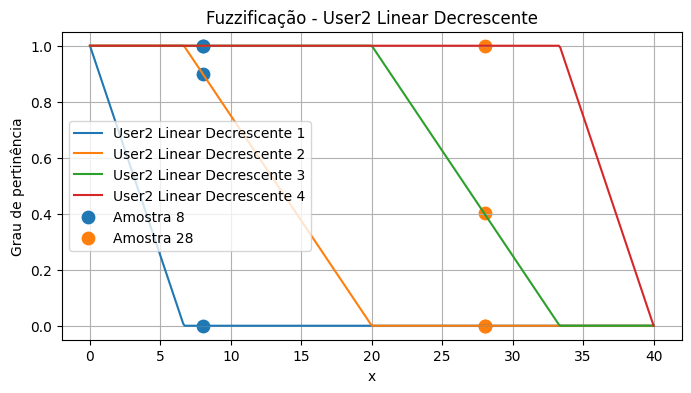

Amostra 8 (User2 Linear Decrescente): ['0.000', '0.898', '1.000', '1.000']
Amostra 28 (User2 Linear Decrescente): ['0.000', '0.000', '0.402', '1.000']

Análise comparativa:
- Funções gaussianas e bell apresentam maior suavidade, com transições suaves entre os graus de pertinência.
- Funções trapezoidais e triangulares têm regiões de transição mais abruptas.
- Funções S e Z são suaves nas extremidades, úteis para limites.
- User1 e User2 são lineares, com sensibilidade constante.
- Cauchy e Gaussiana Dupla apresentam comportamentos intermediários.
- O grau de ativação para cada amostra pode variar bastante conforme a função, sendo mais distribuído nas suaves e mais localizado nas abruptas.


In [29]:
# 1.2 Fuzzificação e Análise Comparativa

# Definindo duas amostras para fuzzificação
amostras = [8, 28]

def plot_fuzzificacao(x, mus, params, nome, amostras):
    plt.figure(figsize=(8, 4))
    for i, mu in enumerate(mus):
        plt.plot(x, mu, label=f'{nome} {i+1}')
    for amostra in amostras:
        ativacoes = [mu[np.abs(x - amostra).argmin()] for mu in mus]
        plt.scatter([amostra]*len(mus), ativacoes, marker='o', s=80, label=f'Amostra {amostra}')
    plt.title(f'Fuzzificação - {nome}')
    plt.xlabel('x')
    plt.ylabel('Grau de pertinência')
    plt.legend()
    plt.grid(True)
    plt.show()
    # Exibe os graus de ativação para cada função
    for idx, amostra in enumerate(amostras):
        ativacoes = [mu[np.abs(x - amostra).argmin()] for mu in mus]
        print(f"Amostra {amostra} ({nome}): {[f'{a:.3f}' for a in ativacoes]}")

# Fuzzificação e plot para cada tipo de função
plot_fuzzificacao(x, mu_tri, params_tri, 'Triangular', amostras)
plot_fuzzificacao(x, mu_trap, params_trap, 'Trapezoidal', amostras)
plot_fuzzificacao(x, mu_gauss, params_gauss, 'Gaussiana', amostras)
plot_fuzzificacao(x, mu_sig, params_sig, 'Sigmoidal', amostras)
plot_fuzzificacao(x, mu_bell, params_bell, 'Bell', amostras)
plot_fuzzificacao(x, mu_s, params_s, 'S', amostras)
plot_fuzzificacao(x, mu_z, params_z, 'Z', amostras)
plot_fuzzificacao(x, mu_cauchy, params_cauchy, 'Cauchy', amostras)
plot_fuzzificacao(x, mu_gd, params_gd, 'Gaussiana Dupla', amostras)
plot_fuzzificacao(x, mu_user1, params_user1, 'User1 Linear Crescente', amostras)
plot_fuzzificacao(x, mu_user2, params_user2, 'User2 Linear Decrescente', amostras)

# Análise textual (exemplo simples)
print("\nAnálise comparativa:")
print("- Funções gaussianas e bell apresentam maior suavidade, com transições suaves entre os graus de pertinência.")
print("- Funções trapezoidais e triangulares têm regiões de transição mais abruptas.")
print("- Funções S e Z são suaves nas extremidades, úteis para limites.")
print("- User1 e User2 são lineares, com sensibilidade constante.")
print("- Cauchy e Gaussiana Dupla apresentam comportamentos intermediários.")
print("- O grau de ativação para cada amostra pode variar bastante conforme a função, sendo mais distribuído nas suaves e mais localizado nas abruptas.")

# 2. Operações Fuzzy

## 2.1 Complemento, União e Interseção

In [30]:
import numpy as np

# Complemento
def complemento_zadeh(mu):
    return 1 - mu

def complemento_sugeno(mu, l=0.5):
    return (1 - mu) / (1 + l * mu)

def complemento_yager(mu, w=2):
    return (1 - mu**w)**(1/w)

# União (t-conormas)
def uniao_maximo(muA, muB):
    return np.maximum(muA, muB)

def uniao_soma_prob(muA, muB):
    return muA + muB - muA * muB

def uniao_soma_limitada(muA, muB):
    return np.minimum(1, muA + muB)

def uniao_soma_drastica(muA, muB):
    return np.where((muA == 1) | (muB == 1), 1, np.maximum(muA, muB))

# Interseção (t-normas)
def inter_minimo(muA, muB):
    return np.minimum(muA, muB)

def inter_produto(muA, muB):
    return muA * muB

def inter_produto_limitado(muA, muB):
    return np.maximum(0, muA + muB - 1)

def inter_produto_drastico(muA, muB):
    return np.where((muA == 1), muB, np.where((muB == 1), muA, 0))

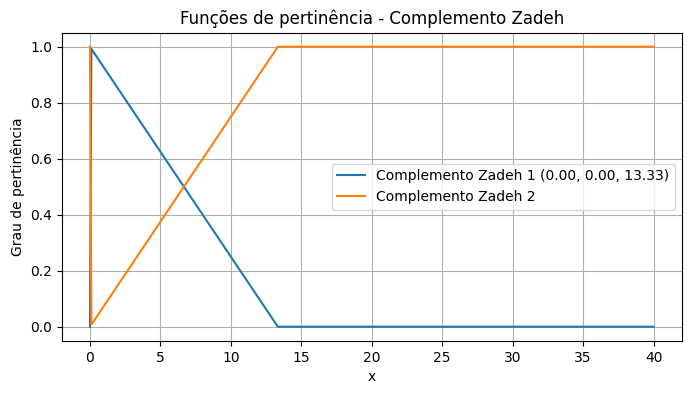

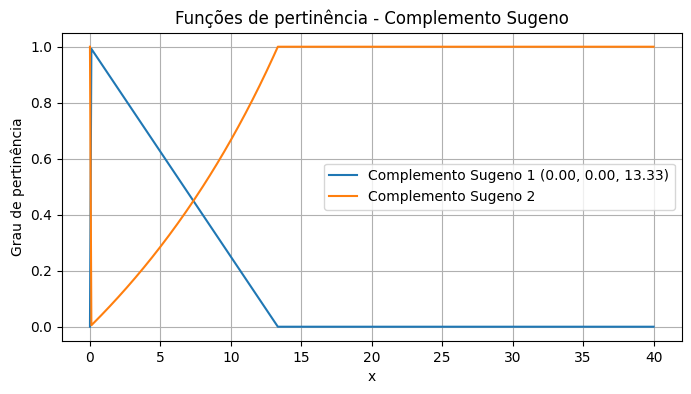

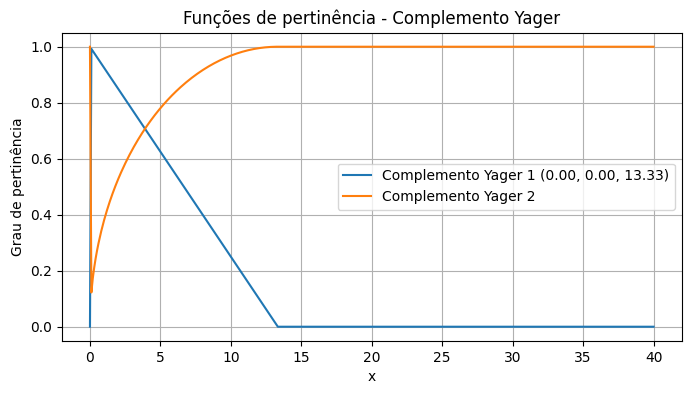

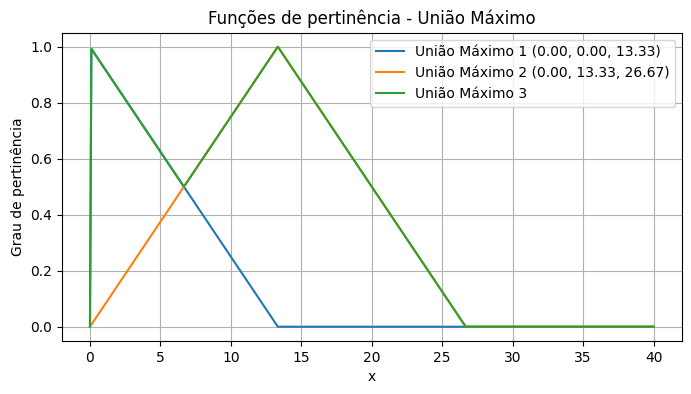

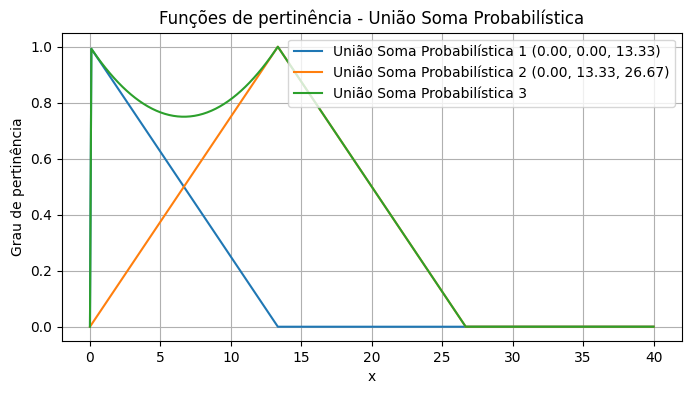

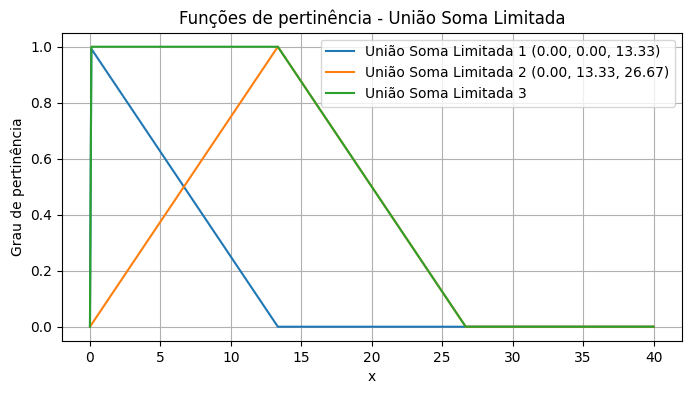

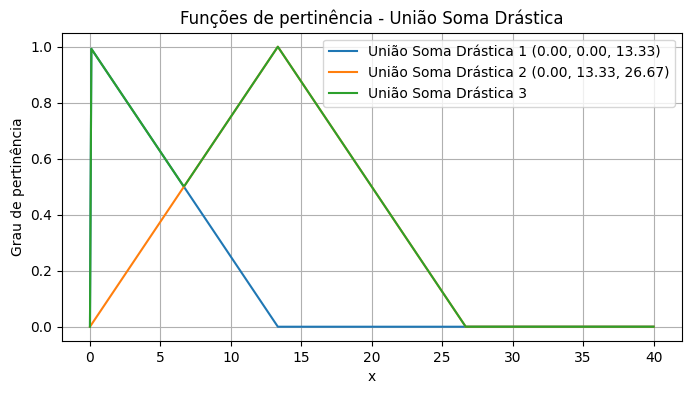

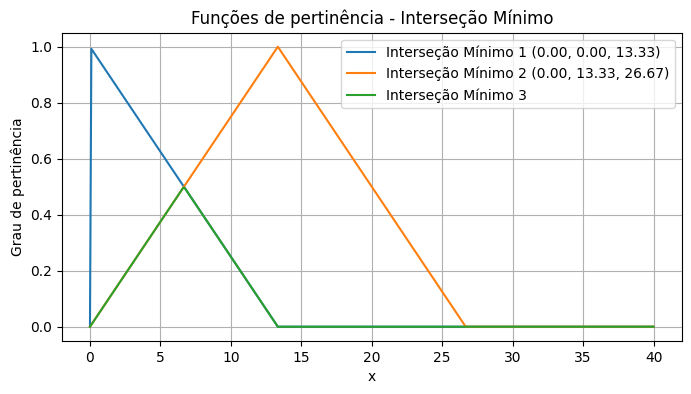

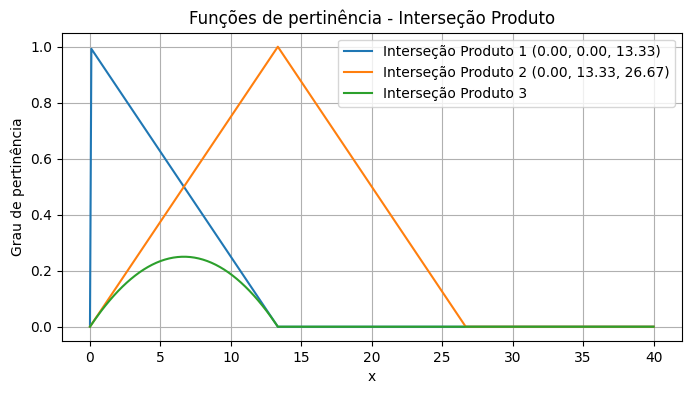

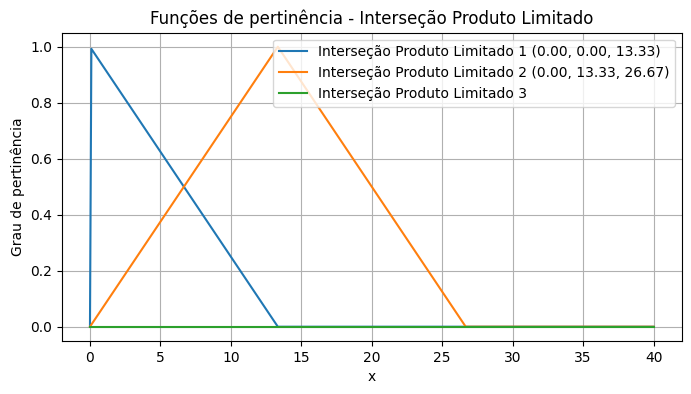

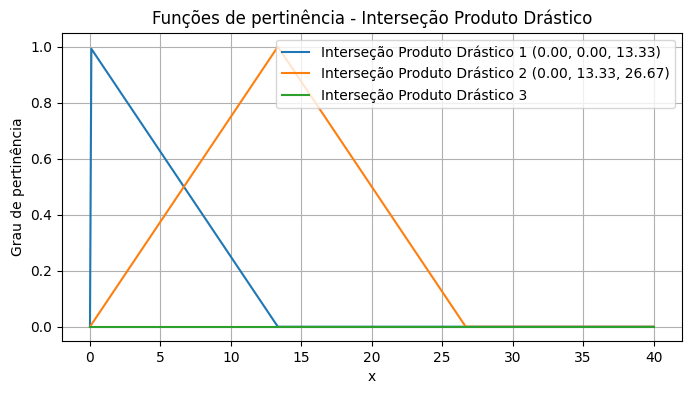

In [31]:
# Selecionando dois conjuntos fuzzy para exemplo
muA = mu_tri[0]
muB = mu_tri[1]
paramsA = [params_tri[0]]
paramsB = [params_tri[1]]
x_plot = x

# Complementos
comp_zadeh = complemento_zadeh(muA)
comp_sugeno = complemento_sugeno(muA)
comp_yager = complemento_yager(muA)

plot_funcoes(x_plot, [muA, comp_zadeh], [paramsA[0], ''], 'Complemento Zadeh')
plot_funcoes(x_plot, [muA, comp_sugeno], [paramsA[0], ''], 'Complemento Sugeno')
plot_funcoes(x_plot, [muA, comp_yager], [paramsA[0], ''], 'Complemento Yager')

# União (t-conormas)
uniao_max = uniao_maximo(muA, muB)
uniao_prob = uniao_soma_prob(muA, muB)
uniao_lim = uniao_soma_limitada(muA, muB)
uniao_drast = uniao_soma_drastica(muA, muB)

plot_funcoes(x_plot, [muA, muB, uniao_max], [paramsA[0], paramsB[0], ''], 'União Máximo')
plot_funcoes(x_plot, [muA, muB, uniao_prob], [paramsA[0], paramsB[0], ''], 'União Soma Probabilística')
plot_funcoes(x_plot, [muA, muB, uniao_lim], [paramsA[0], paramsB[0], ''], 'União Soma Limitada')
plot_funcoes(x_plot, [muA, muB, uniao_drast], [paramsA[0], paramsB[0], ''], 'União Soma Drástica')

# Interseção (t-normas)
inter_min = inter_minimo(muA, muB)
inter_prod = inter_produto(muA, muB)
inter_lim = inter_produto_limitado(muA, muB)
inter_drast = inter_produto_drastico(muA, muB)

plot_funcoes(x_plot, [muA, muB, inter_min], [paramsA[0], paramsB[0], ''], 'Interseção Mínimo')
plot_funcoes(x_plot, [muA, muB, inter_prod], [paramsA[0], paramsB[0], ''], 'Interseção Produto')
plot_funcoes(x_plot, [muA, muB, inter_lim], [paramsA[0], paramsB[0], ''], 'Interseção Produto Limitado')
plot_funcoes(x_plot, [muA, muB, inter_drast], [paramsA[0], paramsB[0], ''], 'Interseção Produto Drástico')

## Análise Comparativa dos Operadores Fuzzy

### Complemento

- **Zadeh:**  
  O complemento de Zadeh é a inversão direta do grau de pertinência: \( 1 - \mu \). É o operador mais comum e apresenta uma transição abrupta entre pertencimento e não pertencimento.

- **Sugeno:**  
  O complemento de Sugeno é mais suave e depende do parâmetro λ (\( l \)). Quanto maior o valor de λ, mais suave é a transição do complemento. Útil quando se deseja um comportamento menos abrupto.

- **Yager:**  
  O complemento de Yager permite controlar a suavidade da transição pelo parâmetro \( w \). Valores maiores de \( w \) tornam o complemento ainda mais suave, sendo útil para ajustar a sensibilidade do operador.

---

### União (t-conormas)

- **Máximo:**  
  Retorna o maior grau de pertinência entre os conjuntos. É o operador padrão e mais utilizado para união fuzzy, sendo bastante "duro" (não suaviza transições).

- **Soma Probabilística:**  
  Considera a sobreposição dos conjuntos, calculando \( \mu_A + \mu_B - \mu_A \cdot \mu_B \). Nunca ultrapassa 1 e suaviza a união, sendo mais realista em muitos cenários.

- **Soma Limitada:**  
  Soma simples dos graus de pertinência, limitada a 1. Pode ser mais agressiva, pois rapidamente atinge o valor máximo.

- **Soma Drástica:**  
  Só retorna 1 se algum dos conjuntos for totalmente pertencente (\( \mu = 1 \)), caso contrário retorna o maior valor. É útil para situações extremas, mas pouco usada na prática.

---

### Interseção (t-normas)

- **Mínimo:**  
  Retorna o menor grau de pertinência entre os conjuntos. É o operador padrão para interseção fuzzy, sendo bastante "duro".

- **Produto:**  
  Multiplica os graus de pertinência, suavizando a interseção. Útil quando se deseja considerar a influência conjunta dos conjuntos.

- **Produto Limitado:**  
  Só é positivo se a soma dos graus for maior que 1 (\( \max(0, \mu_A + \mu_B - 1) \)), caso contrário é 0. É mais restritivo e pode ser útil em aplicações específicas.

- **Produto Drástico:**  
  Só retorna o valor do outro conjunto se um deles for totalmente pertencente (\( \mu = 1 \)), caso contrário retorna 0. Também é um operador extremo, pouco usado em aplicações práticas.

---

### Resumo Visual

- **Operadores padrão** (máximo/mínimo) são mais "duros", com transições abruptas.
- **Operadores probabilísticos e suaves** (produto, sugeno, yager) permitem transições mais graduais e realistas.
- **Operadores drásticos** são úteis para situações extremas, mas raramente utilizados em aplicações reais.

Os gráficos gerados mostram claramente essas diferenças: operadores suaves apresentam curvas mais arredondadas e transições menos abruptas, enquanto operadores duros e drásticos apresentam mudanças bruscas nos graus de pertinência.

## 2.2 Relações Fuzzy

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def matriz_relacao_fuzzy(muA, muB, operador):
    """
    Calcula a matriz de relação fuzzy entre dois conjuntos fuzzy usando o operador fornecido.
    muA: vetor de pertinência do conjunto A (tamanho n)
    muB: vetor de pertinência do conjunto B (tamanho m)
    operador: função t-norma ou s-norma (ex: np.minimum, np.maximum, etc)
    Retorna: matriz (n x m)
    """
    n = len(muA)
    m = len(muB)
    matriz = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            matriz[i, j] = operador(muA[i], muB[j])
    return matriz

# Exemplos de operadores
def tnorma_min(a, b):
    return np.minimum(a, b)

def tnorma_prod(a, b):
    return a * b

def snorma_max(a, b):
    return np.maximum(a, b)

def snorma_soma_prob(a, b):
    return a + b - a * b

# Selecionando dois conjuntos fuzzy para exemplo
muA = mu_tri[0]
muB = mu_tri[1]

# Calculando as matrizes de relação
mat_min = matriz_relacao_fuzzy(muA, muB, tnorma_min)
mat_prod = matriz_relacao_fuzzy(muA, muB, tnorma_prod)
mat_max = matriz_relacao_fuzzy(muA, muB, snorma_max)
mat_soma_prob = matriz_relacao_fuzzy(muA, muB, snorma_soma_prob)

# Função para plotar a matriz de relação fuzzy
def plot_matriz_relacao(matriz, titulo):
    plt.figure(figsize=(6, 5))
    plt.imshow(matriz, origin='lower', aspect='auto', cmap='viridis')
    plt.colorbar(label='Grau de relação')
    plt.title(titulo)
    plt.xlabel('Índice B')
    plt.ylabel('Índice A')
    plt.tight_layout()
    plt.show()

# Plotando as matrizes
plot_matriz_relacao(mat_min, 'Relação Fuzzy (T-norma Mínimo)')
plot_matriz_relacao(mat_prod, 'Relação Fuzzy (T-norma Produto)')
plot_matriz_relacao(mat_max, 'Relação Fuzzy (S-norma Máximo)')
plot_matriz_relacao(mat_soma_prob, 'Relação Fuzzy (S-norma Soma Probabilística)')

# Análise comparativa
print("""
## Análise Comparativa das Relações Fuzzy

- **T-norma Mínimo:** A matriz mostra valores altos apenas quando ambos os conjuntos têm alta pertinência. É mais restritiva.
- **T-norma Produto:** Produz valores intermediários, suavizando a relação quando ambos têm pertinência parcial.
- **S-norma Máximo:** Destaca qualquer pertinência alta em A ou B, resultando em uma matriz com mais valores elevados.
- **S-norma Soma Probabilística:** Suaviza ainda mais, permitindo que a relação seja alta mesmo quando apenas um dos conjuntos tem pertinência moderada.

Visualmente, as t-normas produzem matrizes mais "esparsas" (com mais zeros), enquanto as s-normas produzem matrizes mais "cheias" (com mais valores altos).
""")

## Explicação da Relação Fuzzy

A função `matriz_relacao_fuzzy` recebe dois vetores de pertinência (um para cada conjunto fuzzy) e um operador (que pode ser uma t-norma ou s-norma). Ela retorna uma matriz onde cada elemento representa o grau de relação fuzzy entre um elemento do primeiro conjunto e um elemento do segundo, de acordo com o operador escolhido.

### Operadores utilizados

- **T-norma (mínimo):** Calcula a relação usando o menor grau de pertinência entre os elementos dos dois conjuntos.
- **T-norma (produto):** Calcula a relação multiplicando os graus de pertinência dos elementos dos dois conjuntos.
- **S-norma (máximo):** Calcula a relação usando o maior grau de pertinência entre os elementos dos dois conjuntos.
- **S-norma (soma probabilística):** Calcula a relação usando a soma probabilística: \( \mu_A + \mu_B - \mu_A \cdot \mu_B \).

### Visualização

Os gráficos gerados mostram as matrizes de relação fuzzy para cada operador. Cada matriz representa como os graus de pertinência dos dois conjuntos se relacionam ponto a ponto, de acordo com o operador escolhido.

### Análise Comparativa

- **T-norma Mínimo:** A matriz mostra valores altos apenas quando ambos os conjuntos têm alta pertinência. É mais restritiva.
- **T-norma Produto:** Produz valores intermediários, suavizando a relação quando ambos têm pertinência parcial.
- **S-norma Máximo:** Destaca qualquer pertinência alta em A ou B, resultando em uma matriz com mais valores elevados.
- **S-norma Soma Probabilística:** Suaviza ainda mais, permitindo que a relação seja alta mesmo quando apenas um dos conjuntos tem pertinência moderada.

Visualmente, as t-normas produzem matrizes mais "esparsas" (com mais zeros), enquanto as s-normas produzem matrizes mais "cheias" (com mais valores altos).

## 2.3 Composição de Relações Fuzzy

Matriz Máximo-Mínimo (5x5):
 [[0.    0.    0.    0.    0.   ]
 [0.    0.992 0.985 0.977 0.97 ]
 [0.    0.985 0.985 0.977 0.97 ]
 [0.    0.977 0.977 0.977 0.97 ]
 [0.    0.97  0.97  0.97  0.97 ]]
Matriz Mínimo-Máximo (5x5):
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
Matriz Máximo-Produto (5x5):
 [[0.    0.    0.    0.    0.   ]
 [0.    0.985 0.978 0.97  0.963]
 [0.    0.978 0.97  0.963 0.955]
 [0.    0.97  0.963 0.955 0.948]
 [0.    0.963 0.955 0.948 0.941]]

Estatísticas Máximo-Mínimo: max = 0.9924812029330827 min = 0.0 média = 0.0364374999972672
Estatísticas Mínimo-Máximo: max = 0.0 min = 0.0 média = 0.0
Estatísticas Máximo-Produto: max = 0.9850189381754989 min = 0.0 média = 0.027224999995916255


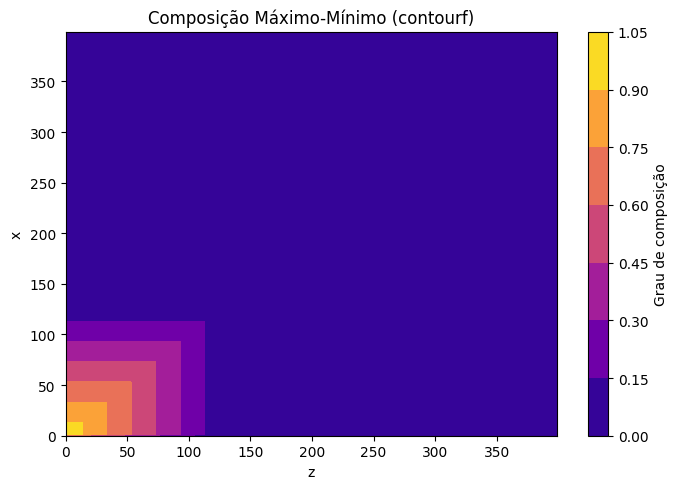

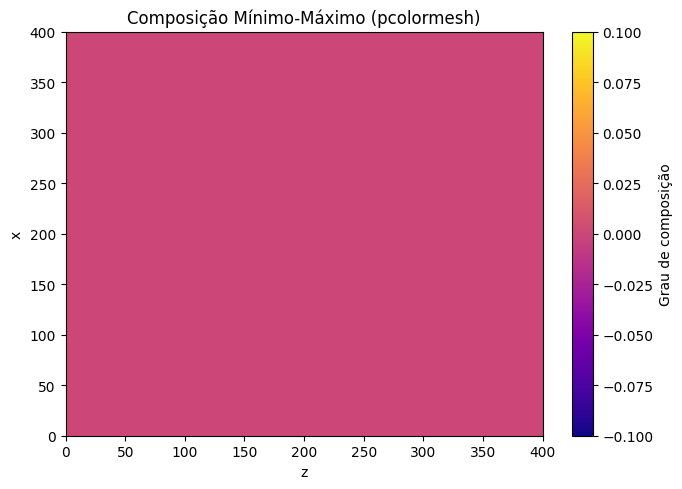

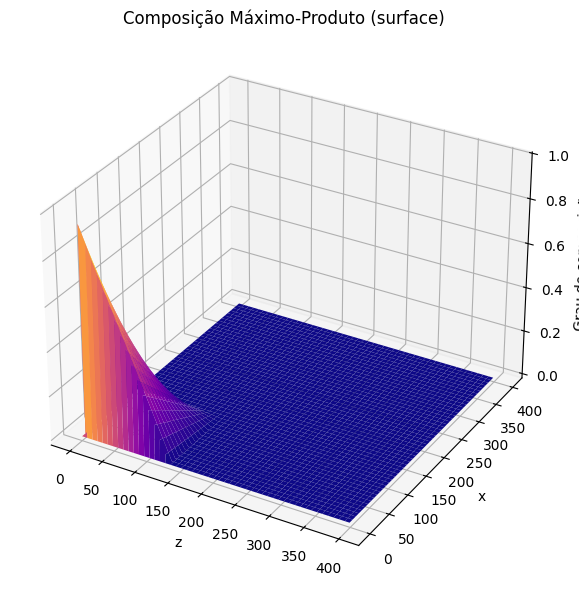


## Análise Comparativa das Composições Fuzzy

- **Máximo-Mínimo:** Destaca as maiores similaridades entre as relações, sendo mais permissivo e resultando em valores mais altos na matriz composta.
- **Mínimo-Máximo:** É mais restritivo, pois considera o menor valor máximo entre as relações, resultando em uma matriz com valores geralmente mais baixos.
- **Máximo-Produto:** Suaviza a composição, levando em conta a influência conjunta dos graus de pertinência, e normalmente apresenta valores intermediários.

Visualmente, a composição Máximo-Mínimo tende a produzir regiões mais amplas de valores altos, enquanto a Mínimo-Máximo é mais seletiva. A Máximo-Produto mostra uma transição suave entre as regiões de maior pertinência.

Além dos gráficos, a análise dos valores das matrizes permite identificar padrões quantitativos e diferenças entre as composições.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def composicao_max_min(A, B):
    """
    Composição Máximo-Mínimo: μR(x, z) = max_y min(μA(x, y), μB(y, z))
    """
    n, m = A.shape[0], B.shape[1]
    R = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            R[i, j] = np.max(np.minimum(A[i, :], B[:, j]))
    return R

def composicao_min_max(A, B):
    """
    Composição Mínimo-Máximo: μR(x, z) = min_y max(μA(x, y), μB(y, z))
    """
    n, m = A.shape[0], B.shape[1]
    R = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            R[i, j] = np.min(np.maximum(A[i, :], B[:, j]))
    return R

def composicao_max_prod(A, B):
    """
    Composição Máximo-Produto: μR(x, z) = max_y (μA(x, y) * μB(y, z))
    """
    n, m = A.shape[0], B.shape[1]
    R = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            R[i, j] = np.max(A[i, :] * B[:, j])
    return R

# Exemplo prático:
# Usando os dois primeiros conjuntos fuzzy triangulares já definidos
muA = mu_tri[0]
muB = mu_tri[1]

# Criando matrizes de relação fuzzy A(x, y) e B(y, z)
A = matriz_relacao_fuzzy(muA, muB, np.minimum)
B = matriz_relacao_fuzzy(muB, muA, np.minimum)

# Composições
R_max_min = composicao_max_min(A, B)
R_min_max = composicao_min_max(A, B)
R_max_prod = composicao_max_prod(A, B)

# Exibir parte dos valores das matrizes
print("Matriz Máximo-Mínimo (5x5):\n", np.round(R_max_min[:5, :5], 3))
print("Matriz Mínimo-Máximo (5x5):\n", np.round(R_min_max[:5, :5], 3))
print("Matriz Máximo-Produto (5x5):\n", np.round(R_max_prod[:5, :5], 3))

# Visualizações alternativas
def plot_matriz_contour(matriz, titulo):
    plt.figure(figsize=(7, 5))
    X, Y = np.meshgrid(np.arange(matriz.shape[1]), np.arange(matriz.shape[0]))
    cp = plt.contourf(X, Y, matriz, cmap='plasma')
    plt.colorbar(cp, label='Grau de composição')
    plt.title(titulo + ' (contourf)')
    plt.xlabel('z')
    plt.ylabel('x')
    plt.tight_layout()
    plt.show()

def plot_matriz_pcolormesh(matriz, titulo):
    plt.figure(figsize=(7, 5))
    X, Y = np.meshgrid(np.arange(matriz.shape[1]+1), np.arange(matriz.shape[0]+1))
    plt.pcolormesh(X, Y, matriz, cmap='plasma', shading='auto')
    plt.colorbar(label='Grau de composição')
    plt.title(titulo + ' (pcolormesh)')
    plt.xlabel('z')
    plt.ylabel('x')
    plt.tight_layout()
    plt.show()

from mpl_toolkits.mplot3d import Axes3D

def plot_matriz_surface(matriz, titulo):
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    X, Y = np.meshgrid(np.arange(matriz.shape[1]), np.arange(matriz.shape[0]))
    ax.plot_surface(X, Y, matriz, cmap='plasma')
    ax.set_title(titulo + ' (surface)')
    ax.set_xlabel('z')
    ax.set_ylabel('x')
    ax.set_zlabel('Grau de composição')
    plt.tight_layout()
    plt.show()

# Plots
plot_matriz_contour(R_max_min, 'Composição Máximo-Mínimo')
plot_matriz_pcolormesh(R_min_max, 'Composição Mínimo-Máximo')
plot_matriz_surface(R_max_prod, 'Composição Máximo-Produto')

# Análise textual em Markdown
from IPython.display import Markdown, display

display(Markdown("""
## Análise Comparativa das Composições Fuzzy

- **Máximo-Mínimo:** Destaca as maiores similaridades entre as relações, sendo mais permissivo e resultando em valores mais altos na matriz composta.
- **Mínimo-Máximo:** É mais restritivo, pois considera o menor valor máximo entre as relações, resultando em uma matriz com valores geralmente mais baixos.
- **Máximo-Produto:** Suaviza a composição, levando em conta a influência conjunta dos graus de pertinência, e normalmente apresenta valores intermediários.

Visualmente, a composição Máximo-Mínimo tende a produzir regiões mais amplas de valores altos, enquanto a Mínimo-Máximo é mais seletiva. A Máximo-Produto mostra uma transição suave entre as regiões de maior pertinência.

Além dos gráficos, a análise dos valores das matrizes permite identificar padrões quantitativos e diferenças entre as composições.
"""))

## Explicação das Composições de Relações Fuzzy

As três composições clássicas de relações fuzzy foram implementadas e aplicadas sobre os conjuntos fuzzy já definidos:

- **Máximo-Mínimo:**  
  Calcula, para cada par (x, z), o maior valor do mínimo entre os graus de pertinência das relações intermediárias. Essa composição destaca as maiores similaridades entre as relações, sendo mais permissiva e resultando em valores mais altos na matriz composta.

- **Mínimo-Máximo:**  
  Calcula, para cada par (x, z), o menor valor do máximo entre os graus de pertinência das relações intermediárias. É mais restritiva, pois considera o menor valor máximo entre as relações, resultando em uma matriz com valores geralmente mais baixos.

- **Máximo-Produto:**  
  Calcula, para cada par (x, z), o maior valor do produto entre os graus de pertinência das relações intermediárias. Suaviza a composição, levando em conta a influência conjunta dos graus de pertinência, e normalmente apresenta valores intermediários.

### Visualização

Os gráficos gerados mostram as diferenças visuais entre as composições.  
- A composição Máximo-Mínimo tende a produzir regiões mais amplas de valores altos.
- A Mínimo-Máximo é mais seletiva, com regiões de valores altos mais restritas.
- A Máximo-Produto mostra uma transição suave entre as regiões de maior pertinência.

### Análise Comparativa

- **Máximo-Mínimo:** Mais permissivo, destaca as maiores similaridades.
- **Mínimo-Máximo:** Mais restritivo, destaca as menores garantias de pertinência.
- **Máximo-Produto:** Suaviza a influência conjunta, ficando entre os dois anteriores.

Essas diferenças são importantes na modelagem fuzzy, pois afetam diretamente o resultado final da composição de relações.